# Section 13: Measuring model performance

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import sklearn.metrics as skm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import scipy.stats as stats
import matplotlib.pyplot as plt
import requests
import io
import time

## APRF in code

In [2]:
n = 50
num_exps = 10000

accuracy = np.zeros(num_exps)
precision = np.zeros(num_exps)
recall = np.zeros(num_exps)
f1_score = np.zeros(num_exps)

for i_exps in range(num_exps):
    tp = np.random.randint(1, n)
    fn = n - tp
    tn = np.random.randint(1, n)
    fp = n - tn
    
    accuracy[i_exps] = (tp + tn) / (2 * n)
    precision[i_exps] = tp / (tp + fp)
    recall[i_exps] = tp / (tp + fn)
    f1_score[i_exps] = tp / (tp + (fp + fn) / 2)

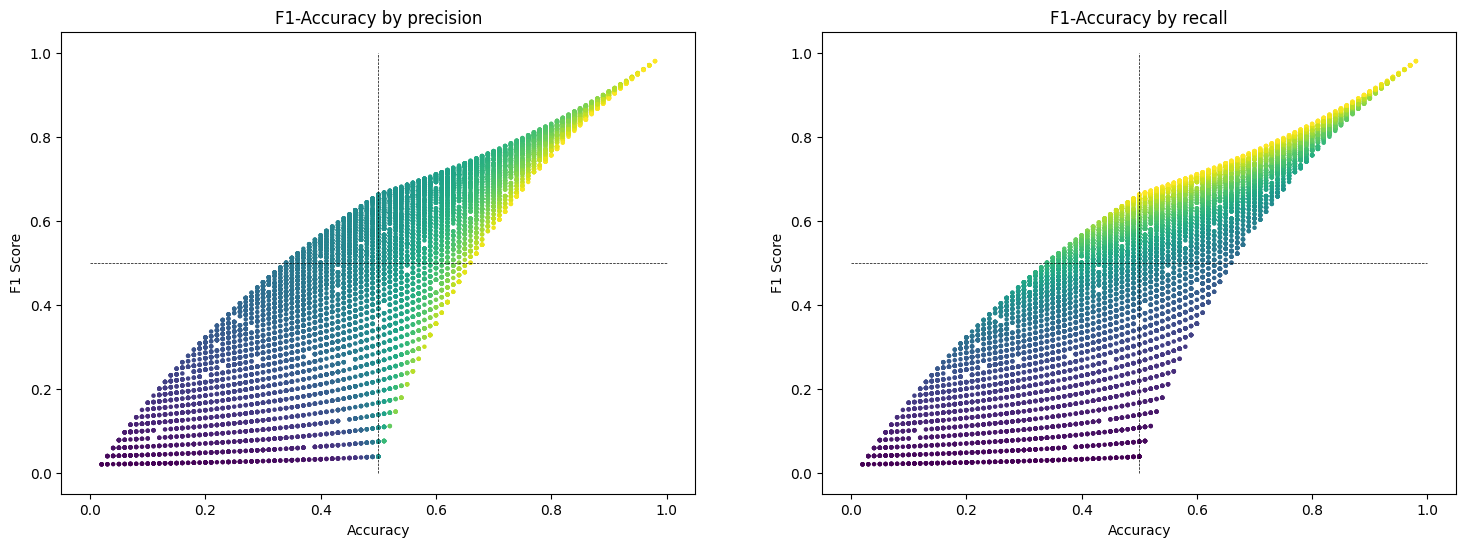

In [3]:
_, ax = plt.subplots(1, 2, figsize=(18, 6))

ax[0].scatter(accuracy, f1_score, s=5, c=precision)
ax[0].plot([0, 1], [.5, .5], 'k--', linewidth=.5)
ax[0].plot([.5, .5], [0, 1], 'k--', linewidth=.5)
ax[0].set_xlabel('Accuracy')
ax[0].set_ylabel('F1 Score')
ax[0].set_title("F1-Accuracy by precision")
ax[1].scatter(accuracy, f1_score, s=5, c=recall)
ax[1].plot([0, 1], [.5, .5], 'k--', linewidth=.5)
ax[1].plot([.5, .5], [0, 1], 'k--', linewidth=.5)
ax[1].set_xlabel('Accuracy')
ax[1].set_ylabel('F1 Score')
ax[1].set_title("F1-Accuracy by recall")
plt.show()

## APRF example 1: wine quality

In [4]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
r = requests.get(url, timeout=30)

r.raise_for_status()

data = pd.read_csv(io.StringIO(r.text), sep=';')
data = data[data["total sulfur dioxide"] < 200]

In [5]:
cols_to_zscore = data.keys()
cols_to_zscore = cols_to_zscore.drop('quality')
data[cols_to_zscore] = data[cols_to_zscore].apply(stats.zscore)

data['boolQuality'] = 0
data.loc[data['quality'] > 5, 'boolQuality'] = 1
data_t = torch.tensor(data[cols_to_zscore].values).float()
labels = torch.tensor(data['boolQuality'].values).float()
labels = labels[:, None]

train_data, test_data, train_labels, test_labels = train_test_split(data_t, labels, test_size=.1)

train_dataset = TensorDataset(train_data, train_labels)
test_dataset = TensorDataset(test_data, test_labels)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

In [6]:
class AnnWine(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.input = nn.Linear(11, 16)
        self.fc1 = nn.Linear(16, 32)
        self.fc2 = nn.Linear(32, 32)
        self.output = nn.Linear(32, 1)
        
    def forward(self, x_param):
        x_local = F.relu(self.input(x_param))
        x_local = F.relu(self.fc1(x_local))
        x_local = F.relu(self.fc2(x_local))
        
        return self.output(x_local)

In [7]:
def train_model(model_param, train_loader_param, test_loader_param):
     loss_fun_local = nn.BCEWithLogitsLoss()
     optimizer_local = torch.optim.SGD(model_param.parameters(), lr=.01)
     
     train_accuracies_local = []
     test_accuracies_local = []
     losses_local = []
     
     for epoch in range(1000):
          batch_accuracies = []
          batch_losses = []
         
          model_param.train()
         
          for X_local, y_local in train_loader_param:
               y_pred = model_param(X_local)
               loss = loss_fun_local(y_pred, y_local)
               
               optimizer_local.zero_grad()
               loss.backward()
               optimizer_local.step()
             
               correct_predictions = ((y_pred > 0) == y_local).float()
             
               batch_accuracies.append(100 * torch.mean(correct_predictions).item())
               batch_losses.append(loss.item())
             
          train_accuracies_local.append(np.mean(batch_accuracies))
          losses_local.append(np.mean(batch_losses))
    
          model_param.eval()
          
          X_local, y_local = next(iter(test_loader_param))
          
          with torch.no_grad():
               y_pred = model_param(X_local)
          
          correct_predictions = ((y_pred > 0) == y_local).float()
          
          test_accuracies_local.append(100 * torch.mean(correct_predictions).item())
     
     return train_accuracies_local, test_accuracies_local, losses_local

In [8]:
wine_net = AnnWine()

_ = train_model(wine_net, train_loader, test_loader)

In [9]:
train_real = train_loader.dataset.tensors[1]
train_real = train_real.detach().cpu().numpy().ravel()

train_preds = wine_net(train_loader.dataset.tensors[0])
train_preds = train_preds.detach().cpu().numpy().ravel()

In [10]:
test_real = test_loader.dataset.tensors[1]
test_real = test_real.detach().cpu().numpy().ravel()

test_preds = wine_net(test_loader.dataset.tensors[0])
test_preds = test_preds.detach().cpu().numpy().ravel()

In [11]:
train_metrics = [0, 0, 0, 0]
test_metrics = [0, 0, 0, 0]

train_metrics[0] = skm.accuracy_score(train_real, train_preds > 0)
train_metrics[1] = skm.precision_score(train_real, train_preds > 0)
train_metrics[2] = skm.recall_score(train_real, train_preds > 0)
train_metrics[3] = skm.f1_score(train_real, train_preds > 0)

test_metrics[0] = skm.accuracy_score(test_real, test_preds > 0)
test_metrics[1] = skm.precision_score(test_real, test_preds > 0)
test_metrics[2] = skm.recall_score(test_real, test_preds > 0)
test_metrics[3] = skm.f1_score(test_real, test_preds > 0)

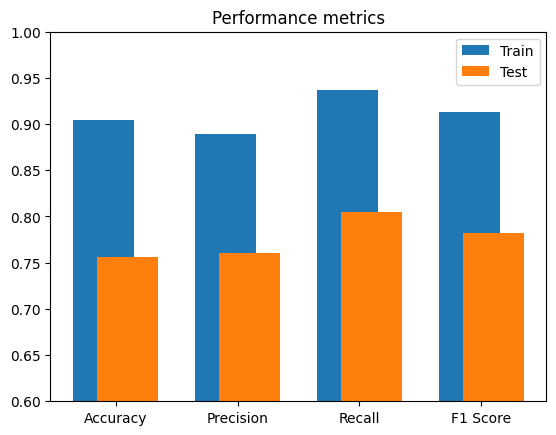

In [12]:
plt.bar(np.arange(4) - .1, train_metrics, .5)
plt.bar(np.arange(4) + .1, test_metrics, .5)
plt.xticks([0, 1, 2, 3], ['Accuracy', 'Precision', 'Recall', 'F1 Score'])
plt.ylim([.6, 1])
plt.legend(['Train', 'Test'])
plt.title("Performance metrics")
plt.show()

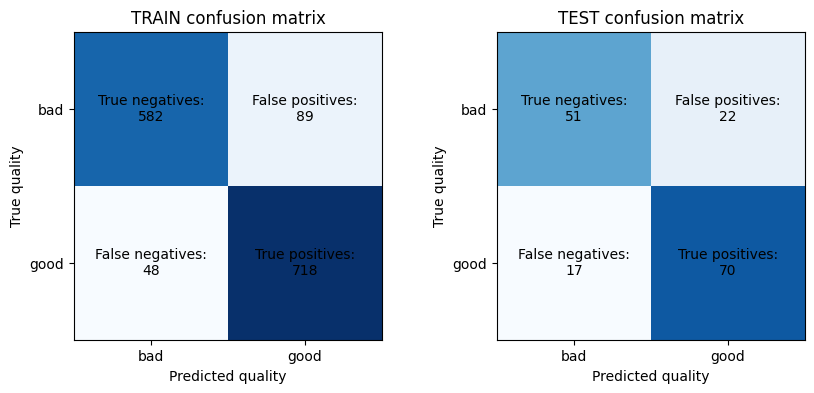

In [13]:
train_conf = skm.confusion_matrix(train_real, train_preds > 0)
test_conf = skm.confusion_matrix(test_real, test_preds > 0)

_, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].imshow(train_conf, 'Blues', vmax=len(train_preds) / 2)
ax[0].set_xticks([0, 1])
ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(['bad', 'good'])
ax[0].set_yticklabels(['bad', 'good'])
ax[0].set_xlabel("Predicted quality")
ax[0].set_ylabel("True quality")
ax[0].set_title("TRAIN confusion matrix")

ax[0].text(0, 0, f"True negatives:\n{train_conf[0, 0]}", ha='center', va='center')
ax[0].text(0, 1, f"False negatives:\n{train_conf[1, 0]}", ha='center', va='center')
ax[0].text(1, 1, f"True positives:\n{train_conf[1, 1]}", ha='center', va='center')
ax[0].text(1, 0, f"False positives:\n{train_conf[0, 1]}", ha='center', va='center')

ax[1].imshow(test_conf, 'Blues', vmax=len(test_preds) / 2)
ax[1].set_xticks([0, 1])
ax[1].set_yticks([0, 1])
ax[1].set_xticklabels(['bad', 'good'])
ax[1].set_yticklabels(['bad', 'good'])
ax[1].set_xlabel("Predicted quality")
ax[1].set_ylabel("True quality")
ax[1].set_title("TEST confusion matrix")

ax[1].text(0, 0, f"True negatives:\n{test_conf[0, 0]}", ha='center', va='center')
ax[1].text(0, 1, f"False negatives:\n{test_conf[1, 0]}", ha='center', va='center')
ax[1].text(1, 1, f"True positives:\n{test_conf[1, 1]}", ha='center', va='center')
ax[1].text(1, 0, f"False positives:\n{test_conf[0, 1]}", ha='center', va='center')

plt.show()

## APRF example 2: MNIST

In [14]:
data = np.loadtxt(open('mnist_train_small.csv', 'rb'), delimiter=',')

X = data[:, 1:]
y = data[:, 0]
X_norm = X / np.max(X)

X_tensor = torch.tensor(X_norm).float()
y_tensor = torch.tensor(y).long()

X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=.1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

In [15]:
def create_model():
    class AnnMnist(nn.Module):
        def __init__(self):
            super().__init__()
            
            self.input = nn.Linear(784, 64)
            self.fully_connected_1 = nn.Linear(64, 32)
            self.fully_connected_2 = nn.Linear(32, 32)
            self.output = nn.Linear(32, 10)
            
        def forward(self, x_param):
            x_local = self.input(x_param)
            x_local = F.relu(x_local)
            x_local = self.fully_connected_1(x_local)
            x_local = F.relu(x_local)
            x_local = self.fully_connected_2(x_local)
            x_local = F.relu(x_local)

            return  self.output(x_local)
    
    ann_mnist_local = AnnMnist()
    loss_function_local = nn.CrossEntropyLoss()
    optimizer_local = torch.optim.Adam(ann_mnist_local.parameters(), lr=.01)
    
    return ann_mnist_local, loss_function_local, optimizer_local

In [16]:
def train_model():
    ann_mnist_local, loss_function_local, optimizer_local = create_model()
    train_accuracies_local = []
    test_accuracies_local = []
    losses_local = []
     
    for epoch in range(10):
        batch_accuracies = []
        batch_losses = []
         
        ann_mnist_local.train()
         
        for X_local, y_local in train_loader:
            y_pred = ann_mnist_local(X_local)
            loss = loss_function_local(y_pred, y_local)
               
            optimizer_local.zero_grad()
            loss.backward()
            optimizer_local.step()
               
            correct_predictions = (torch.argmax(y_pred, axis=1) == y_local).float()
             
            batch_accuracies.append(100 * torch.mean(correct_predictions).item())
            batch_losses.append(loss.item())

        train_accuracies_local.append(np.mean(batch_accuracies))
        losses_local.append(np.mean(batch_losses))
    
        ann_mnist_local.eval()
          
        X_local, y_local = next(iter(test_loader))
          
        with torch.no_grad():
            y_pred = ann_mnist_local(X_local)
          
        correct_predictions = (torch.argmax(y_pred, axis=1) == y_local).float()
          
        test_accuracies_local.append(100 * torch.mean(correct_predictions).item())
     
    return train_accuracies_local, test_accuracies_local, losses_local, ann_mnist_local

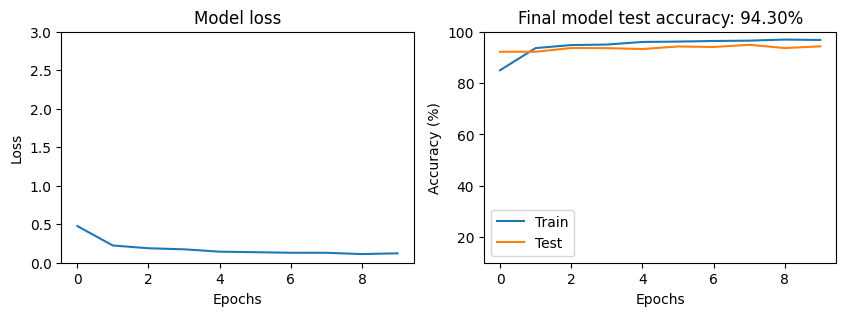

In [17]:
train_acc, test_acc, losses, net = train_model()

_, ax = plt.subplots(1, 2, figsize=(10, 3))

ax[0].plot(losses)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_ylim([0, 3])
ax[0].set_title("Model loss")

ax[1].plot(train_acc, label='Train')
ax[1].plot(test_acc, label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel("Accuracy (%)")
ax[1].set_ylim([10, 100])
ax[1].set_title(f"Final model test accuracy: {test_acc[-1]:.2f}%")
ax[1].legend()

plt.show()

In [18]:
train_real = train_loader.dataset.tensors[1]
train_real = train_real.detach().cpu().numpy().ravel()

train_preds = net(train_loader.dataset.tensors[0])
train_preds = torch.argmax(train_preds, axis=1)
train_preds = train_preds.detach().cpu().numpy().ravel()

test_real = test_loader.dataset.tensors[1]
test_real = test_real.detach().cpu().numpy().ravel()

test_preds = net(test_loader.dataset.tensors[0])
test_preds = torch.argmax(test_preds, axis=1)
test_preds = test_preds.detach().cpu().numpy().ravel()

In [19]:
train_metrics = [0, 0, 0, 0]
test_metrics = [0, 0, 0, 0]

train_metrics[0] = skm.accuracy_score(train_real, train_preds)
train_metrics[1] = skm.precision_score(train_real, train_preds, average='weighted')
train_metrics[2] = skm.recall_score(train_real, train_preds, average='weighted')
train_metrics[3] = skm.f1_score(train_real, train_preds, average='weighted')

test_metrics[0] = skm.accuracy_score(test_real, test_preds)
test_metrics[1] = skm.precision_score(test_real, test_preds, average='weighted')
test_metrics[2] = skm.recall_score(test_real, test_preds, average='weighted')
test_metrics[3] = skm.f1_score(test_real, test_preds, average='weighted')

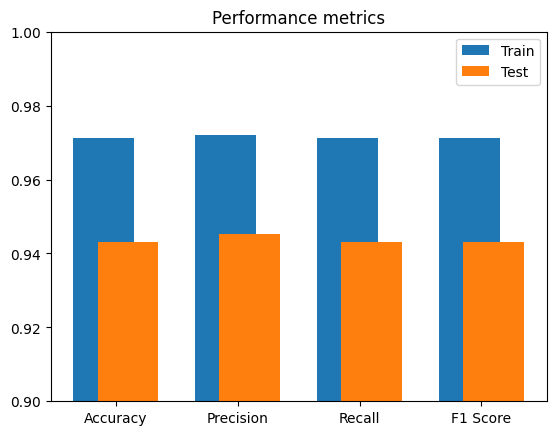

In [20]:
plt.bar(np.arange(4) - .1, train_metrics, .5)
plt.bar(np.arange(4) + .1, test_metrics, .5)
plt.xticks([0, 1, 2, 3], ['Accuracy', 'Precision', 'Recall', 'F1 Score'])
plt.ylim([.9, 1])
plt.legend(['Train', 'Test'])
plt.title("Performance metrics")
plt.show()

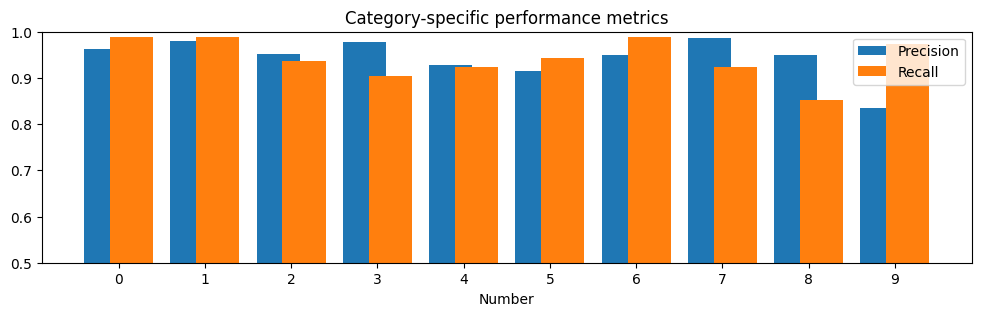

In [21]:
precision = skm.precision_score(test_real, test_preds, average=None)
recall = skm.recall_score(test_real, test_preds, average=None)

plt.figure(figsize=(12, 3))
plt.bar(np.arange(10) - .15, precision, .5)
plt.bar(np.arange(10) + .15, recall, .5)
plt.xticks(range(10), range(10))
plt.ylim([.5, 1])
plt.xlabel('Number')
plt.legend(['Precision', 'Recall'])
plt.title("Category-specific performance metrics")
plt.show()

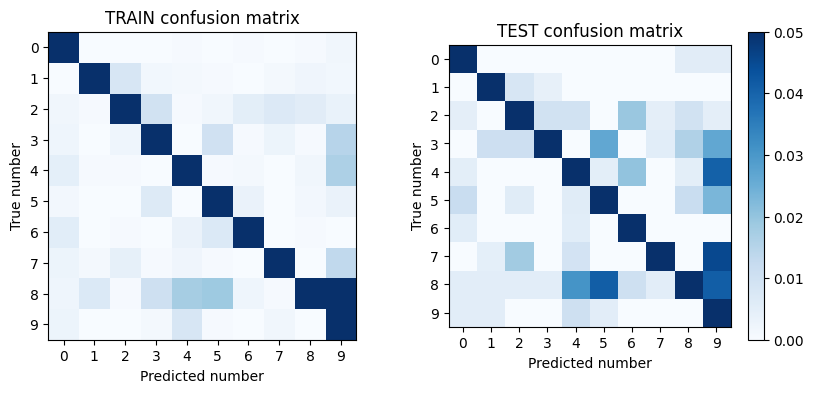

In [22]:
train_conf = skm.confusion_matrix(train_real, train_preds, normalize='true')
test_conf = skm.confusion_matrix(test_real, test_preds, normalize='true')

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].imshow(train_conf, 'Blues', vmax=.05)
ax[0].set_xticks(range(10))
ax[0].set_yticks(range(10))
ax[0].set_title("TRAIN confusion matrix")
ax[0].set_xlabel("True number")
ax[0].set_xlabel("Predicted number")
ax[0].set_ylabel("True number")

a = ax[1].imshow(test_conf, cmap='Blues', vmax=.05)

ax[1].set_xticks(range(10))
ax[1].set_yticks(range(10))
ax[1].set_title("TEST confusion matrix")
ax[1].set_xlabel("Predicted number")
ax[1].set_ylabel("True number")

fig.colorbar(a)
plt.show()

## CodeChallenge: MNIST with unequal groups

In [23]:
data = np.loadtxt(open('mnist_train_small.csv', 'rb'), delimiter=',')
seven_indexes = data[:, 0] == 7

data_all_sevens = np.copy(data[seven_indexes])
data_500_sevens = np.copy(data_all_sevens[np.random.randint(1, len(data_all_sevens), 500), :])
data_without_sevens = np.copy(data[~seven_indexes])
data = np.concatenate([data_without_sevens, data_500_sevens], axis=0)

print(data_all_sevens.shape)
print(data_500_sevens.shape)
print(data_without_sevens.shape)
print(data.shape)

(2126, 785)
(500, 785)
(17874, 785)
(18374, 785)


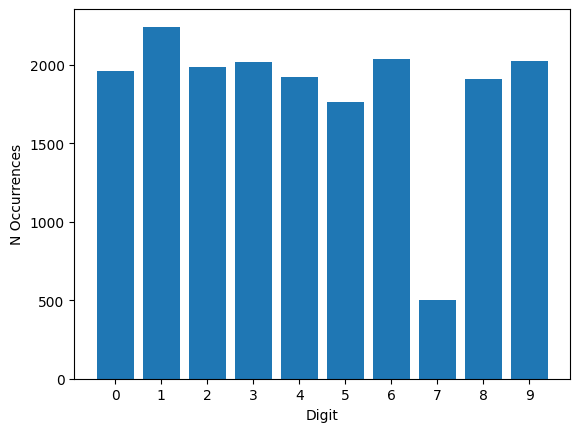

In [24]:
plt.bar(np.arange(10), np.bincount(np.int64(data[:, 0])))
plt.xticks(np.arange(10))
plt.ylabel("N Occurrences")
plt.xlabel('Digit')
plt.show()

In [25]:
X = data[:, 1:]
y = data[:, 0]
X_norm = X / np.max(X)

X_tensor = torch.tensor(X_norm).float()
y_tensor = torch.tensor(y).long()

X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=.1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

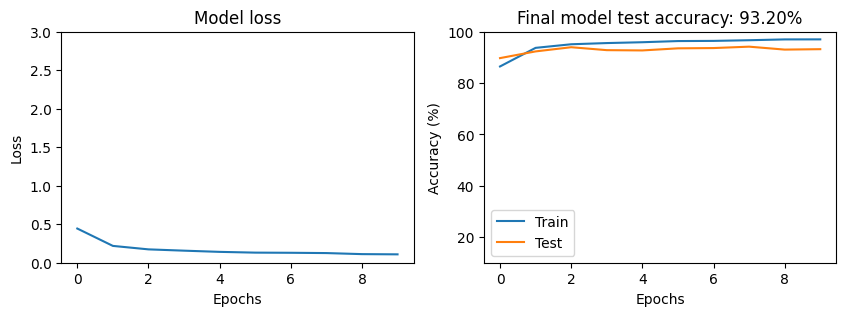

In [26]:
train_acc, test_acc, losses, net = train_model()

_, ax = plt.subplots(1, 2, figsize=(10, 3))

ax[0].plot(losses)
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].set_ylim([0, 3])
ax[0].set_title("Model loss")

ax[1].plot(train_acc, label='Train')
ax[1].plot(test_acc, label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel("Accuracy (%)")
ax[1].set_ylim([10, 100])
ax[1].set_title(f"Final model test accuracy: {test_acc[-1]:.2f}%")
ax[1].legend()

plt.show()

In [27]:
train_real = train_loader.dataset.tensors[1]
train_real = train_real.detach().cpu().numpy().ravel()

train_preds = net(train_loader.dataset.tensors[0])
train_preds = torch.argmax(train_preds, axis=1)
train_preds = train_preds.detach().cpu().numpy().ravel()

test_real = test_loader.dataset.tensors[1]
test_real = test_real.detach().cpu().numpy().ravel()

test_preds = net(test_loader.dataset.tensors[0])
test_preds = torch.argmax(test_preds, axis=1)
test_preds = test_preds.detach().cpu().numpy().ravel()

In [28]:
train_metrics = [0, 0, 0, 0]
test_metrics = [0, 0, 0, 0]

train_metrics[0] = skm.accuracy_score(train_real, train_preds)
train_metrics[1] = skm.precision_score(train_real, train_preds, average='weighted')
train_metrics[2] = skm.recall_score(train_real, train_preds, average='weighted')
train_metrics[3] = skm.f1_score(train_real, train_preds, average='weighted')

test_metrics[0] = skm.accuracy_score(test_real, test_preds)
test_metrics[1] = skm.precision_score(test_real, test_preds, average='weighted')
test_metrics[2] = skm.recall_score(test_real, test_preds, average='weighted')
test_metrics[3] = skm.f1_score(test_real, test_preds, average='weighted')

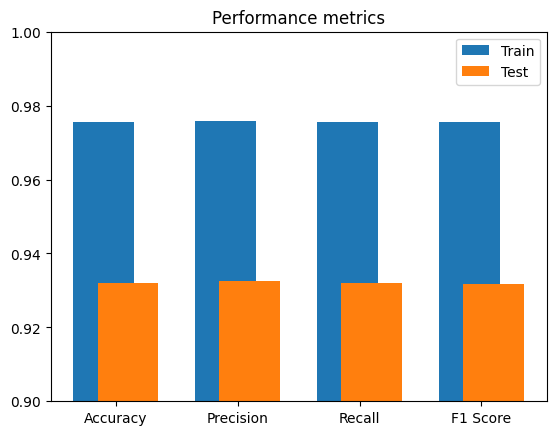

In [29]:
plt.bar(np.arange(4) - .1, train_metrics, .5)
plt.bar(np.arange(4) + .1, test_metrics, .5)
plt.xticks([0, 1, 2, 3], ['Accuracy', 'Precision', 'Recall', 'F1 Score'])
plt.ylim([.9, 1])
plt.legend(['Train', 'Test'])
plt.title("Performance metrics")
plt.show()

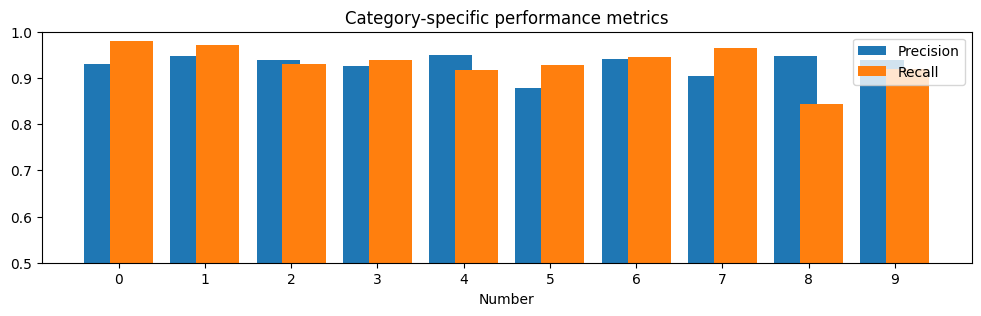

In [30]:
precision = skm.precision_score(test_real, test_preds, average=None)
recall = skm.recall_score(test_real, test_preds, average=None)

plt.figure(figsize=(12, 3))
plt.bar(np.arange(10) - .15, precision, .5)
plt.bar(np.arange(10) + .15, recall, .5)
plt.xticks(range(10), range(10))
plt.ylim([.5, 1])
plt.xlabel('Number')
plt.legend(['Precision', 'Recall'])
plt.title("Category-specific performance metrics")
plt.show()

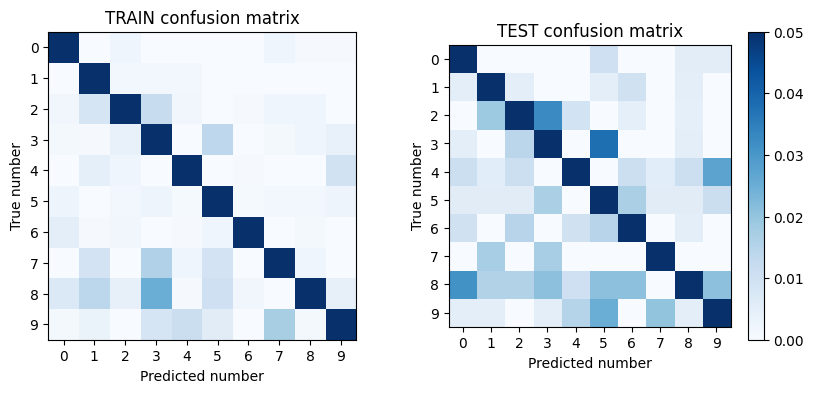

In [31]:
train_conf = skm.confusion_matrix(train_real, train_preds, normalize='true')
test_conf = skm.confusion_matrix(test_real, test_preds, normalize='true')

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].imshow(train_conf, 'Blues', vmax=.05)
ax[0].set_xticks(range(10))
ax[0].set_yticks(range(10))
ax[0].set_title("TRAIN confusion matrix")
ax[0].set_xlabel("True number")
ax[0].set_xlabel("Predicted number")
ax[0].set_ylabel("True number")

a = ax[1].imshow(test_conf, cmap='Blues', vmax=.05)

ax[1].set_xticks(range(10))
ax[1].set_yticks(range(10))
ax[1].set_title("TEST confusion matrix")
ax[1].set_xlabel("Predicted number")
ax[1].set_ylabel("True number")

fig.colorbar(a)
plt.show()

## Computation time

In [32]:
data = np.loadtxt(open('mnist_train_small.csv', 'rb'), delimiter=',')

X = data[:, 1:]
y = data[:, 0]
X_norm = X / np.max(X)

X_tensor = torch.tensor(X_norm).float()
y_tensor = torch.tensor(y).long()

X_train, X_test, y_train, y_test = train_test_split(X_tensor, y_tensor, test_size=.1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0])

In [33]:
def train_model():
    timer_in_function = time.process_time()
    
    ann_mnist_local, loss_function_local, optimizer_local = create_model()
    train_accuracies_local = []
    test_accuracies_local = []
    losses_local = []
     
    for epoch in range(10):
        batch_accuracies = []
        batch_losses = []
         
        ann_mnist_local.train()
         
        for X_local, y_local in train_loader:
            y_pred = ann_mnist_local(X_local)
            loss = loss_function_local(y_pred, y_local)
               
            optimizer_local.zero_grad()
            loss.backward()
            optimizer_local.step()
               
            correct_predictions = (torch.argmax(y_pred, axis=1) == y_local).float()
             
            batch_accuracies.append(100 * torch.mean(correct_predictions).item())
            batch_losses.append(loss.item())

        train_accuracies_local.append(np.mean(batch_accuracies))
        losses_local.append(np.mean(batch_losses))
    
        ann_mnist_local.eval()
          
        X_local, y_local = next(iter(test_loader))
          
        with torch.no_grad():
            y_pred = ann_mnist_local(X_local)
          
        correct_predictions = (torch.argmax(y_pred, axis=1) == y_local).float()
          
        test_accuracies_local.append(100 * torch.mean(correct_predictions).item())
        
        comp_time = time.process_time() - timer_in_function
        
        print(f"Epoch {epoch + 1} / {10}, elapsed time: {comp_time:.2f} sec, test accuracy: {test_acc[-1]:.0f}%")
     
    return train_accuracies_local, test_accuracies_local, losses_local, ann_mnist_local

In [34]:
_ = train_model()

Epoch 1 / 10, elapsed time: 0.38 sec, test accuracy: 93%
Epoch 2 / 10, elapsed time: 0.83 sec, test accuracy: 93%
Epoch 3 / 10, elapsed time: 1.23 sec, test accuracy: 93%
Epoch 4 / 10, elapsed time: 1.60 sec, test accuracy: 93%
Epoch 5 / 10, elapsed time: 1.96 sec, test accuracy: 93%
Epoch 6 / 10, elapsed time: 2.36 sec, test accuracy: 93%
Epoch 7 / 10, elapsed time: 2.74 sec, test accuracy: 93%
Epoch 8 / 10, elapsed time: 3.12 sec, test accuracy: 93%
Epoch 9 / 10, elapsed time: 3.51 sec, test accuracy: 93%
Epoch 10 / 10, elapsed time: 3.90 sec, test accuracy: 93%


In [35]:
timer_outside_function = time.process_time()

for i in range(10):
    print(f"{i + 1}. run:")

    train_model()
    
total_experiments_time = time.process_time() - timer_outside_function

print(f"Total elapsed experiment time: {total_experiments_time/60:.2f} minutes")

1. run:
Epoch 1 / 10, elapsed time: 0.38 sec, test accuracy: 93%
Epoch 2 / 10, elapsed time: 0.76 sec, test accuracy: 93%
Epoch 3 / 10, elapsed time: 1.15 sec, test accuracy: 93%
Epoch 4 / 10, elapsed time: 1.52 sec, test accuracy: 93%
Epoch 5 / 10, elapsed time: 1.88 sec, test accuracy: 93%
Epoch 6 / 10, elapsed time: 2.26 sec, test accuracy: 93%
Epoch 7 / 10, elapsed time: 2.64 sec, test accuracy: 93%
Epoch 8 / 10, elapsed time: 3.03 sec, test accuracy: 93%
Epoch 9 / 10, elapsed time: 3.41 sec, test accuracy: 93%
Epoch 10 / 10, elapsed time: 3.80 sec, test accuracy: 93%
2. run:
Epoch 1 / 10, elapsed time: 0.38 sec, test accuracy: 93%
Epoch 2 / 10, elapsed time: 0.77 sec, test accuracy: 93%
Epoch 3 / 10, elapsed time: 1.16 sec, test accuracy: 93%
Epoch 4 / 10, elapsed time: 1.54 sec, test accuracy: 93%
Epoch 5 / 10, elapsed time: 1.93 sec, test accuracy: 93%
Epoch 6 / 10, elapsed time: 2.31 sec, test accuracy: 93%
Epoch 7 / 10, elapsed time: 2.69 sec, test accuracy: 93%
Epoch 8 / 10, 